# Notebook 15 — MJO SSL Temporal 2D Encoder
**Project:** ENSO-BSISO SSL — MJO Extension  
**Author:** Jiayi (jh9141@nyu.edu)

Self-supervised temporal 2D encoder for MJO. Pairs defined by **temporal proximity only** (no RMM/ENSO labels). Exact analog of `nb08` (BSISO SSL), with two key adaptations:

1. **20–90 day Lanczos bandpass** (Q4 = B from Session 20) — standard MJO band, replaces nb08's 25-day lowpass.  
2. **All-year continuous data** — bandpass applied to the full 1979–2023 time series (no per-year fragmentation, unlike BSISO MJJAS).

## Setup (locked decisions)

| Knob | Value | Source |
|---|---|---|
| Input | `X_MJO.npy`, shape `(N, 3, 1, 180)` | nb13 |
| Embedding dim | 2 (no L2 norm) | nb07c/nb08 lesson |
| Loss | raw dot product InfoNCE | nb08 |
| Temperature τ | 0.5 | nb08 |
| Weight decay | 1e-4 | nb08 |
| Optimizer | Adam, lr=1e-3, cosine→1e-5 | nb08 |
| Epochs | 50 | nb08 |
| Architecture | Conv2d kernel=(1,3), pool=(1,2) | Q5 |
| **Bandpass** | **Lanczos 20–90 day** (low=20d, high=90d, half_w=90) | **Q4 = B** |
| Edge drop | 90 days from each end of full record | filter edge effects |
| Positive pair | anchor d, positive in [d−3, d+3] \ {d}, same year | nb08 |
| Year split | every 5th year held out | nb04/nb07c/nb08 |

## Outputs

- `MJO/checkpoints/encoder_mjo_ssl_final.pth`
- `MJO/data/processed/X_MJO_bp20_90.npy` — bandpassed input (saved for reuse by nb16)
- `MJO/data/processed/labels_aligned_mjo_bp20_90.csv` — labels after edge drops
- `MJO/results/ssl/embeddings.npy`, `training_curves.png`, `embedding_2d_overview.png`, `month_clustering_check.png`, `linear_probe_results.json`, `enso_displacement.png`, `mjo_ssl_summary.md`

## Runtime
Bandpass: ~2 min. Training: ~30–45 min on T4. Total ~35–50 min.

---

## Cell 1 — Mount Drive + Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d

EMBEDDING_DIM   = 2
RUN_TAG         = 'mjo_ssl_fixed'
TEMPERATURE     = 0.07
EPOCHS          = 50
BATCH_SIZE      = 64
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
USE_VICREG      = True
VICREG_VAR      = 25.0
VICREG_COV      = 1.0
MAX_DELTA       = 3        # positive pair window: [d-3, d+3] \ {d}, same year
BP_LOW_DAYS     = 20       # passes periods ≥ 20 days (removes synoptic noise)
BP_HIGH_DAYS    = 90       # passes periods ≤ 90 days (removes ENSO and seasonal residual)
BP_HALF_W       = 90       # filter half-window in days (filter length = 181)
EDGE_DROP_DAYS  = BP_HALF_W

PROJECT_DIR    = '/content/drive/MyDrive/BSISO_SSL_Project'
MJO_DIR        = f'{PROJECT_DIR}/MJO'
PROCESSED_DIR  = f'{MJO_DIR}/data/processed'
CHECKPOINT_DIR = f'{MJO_DIR}/checkpoints'
RESULTS_DIR    = f'{MJO_DIR}/results/ssl'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

X_FILE         = 'X_MJO.npy'
LABELS_FILE    = 'labels_aligned_mjo.csv'
X_BP_FILE      = 'X_MJO_bp20_90.npy'
LABELS_BP_FILE = 'labels_aligned_mjo_bp20_90.csv'

# Clear stale outputs from any prior runs
stale = (glob.glob(f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_*.pth') +
         glob.glob(f'{CHECKPOINT_DIR}/training_history_{RUN_TAG}.json') +
         glob.glob(f'{RESULTS_DIR}/*'))
for p in stale:
    try: os.remove(p)
    except (IsADirectoryError, FileNotFoundError): pass
print(f'Cleared {len(stale)} stale files from previous runs.')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:           {device}')
print(f'Embedding dim:    {EMBEDDING_DIM} (no L2 normalization)')
print(f'Loss:             raw dot product InfoNCE (τ={TEMPERATURE})')
print(f'Bandpass:         Lanczos {BP_LOW_DAYS}–{BP_HIGH_DAYS} d  (half_w={BP_HALF_W}, edge drop ±{EDGE_DROP_DAYS} d)')
print(f'Positive pair:    [d−{MAX_DELTA}, d+{MAX_DELTA}] \\ {{d}}, same year')
print(f'Run tag:          {RUN_TAG}')

Mounted at /content/drive
Cleared 0 stale files from previous runs.
Device:           cuda
Embedding dim:    2 (no L2 normalization)
Loss:             raw dot product InfoNCE (τ=0.5)
Bandpass:         Lanczos 20–90 d  (half_w=90, edge drop ±90 d)
Positive pair:    [d−3, d+3] \ {d}, same year
Run tag:          mjo_ssl


## Cell 2 — Load Data

In [2]:
X      = np.load(f'{PROCESSED_DIR}/{X_FILE}')
labels = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_FILE}', parse_dates=['date'])

print(f'X shape:  {X.shape}  (expect (N, 3, 1, 180))')
print(f'Labels:   {len(labels)} rows')
assert X.shape[0] == len(labels), 'X / labels length mismatch'
assert X.shape[1:] == (3, 1, 180), f'Unexpected shape {X.shape[1:]}'

print(f'\nDate range:    {labels["date"].min().date()} to {labels["date"].max().date()}')
print(f'Month coverage: {sorted(labels["date"].dt.month.unique())}')

X shape:  (16436, 3, 1, 180)  (expect (N, 3, 1, 180))
Labels:   16436 rows

Date range:    1979-01-01 to 2023-12-31
Month coverage: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


## Cell 3 — Lanczos 20–90 day Bandpass

**Filter design** (Q4 = B):
- Bandpass = lowpass(20d) − lowpass(90d) → passes periods in (20, 90) d.
  - Lowpass(20d) keeps periods > 20d (loose).
  - Lowpass(90d) keeps periods > 90d (strict).
  - Difference keeps periods in (20, 90) d — the standard MJO band.
- Half-window 90 days → filter length 181 (sufficient for the 90-day cutoff).
- Applied to the **full continuous time series** (all-year data, unlike BSISO MJJAS per-year).
- Drop first/last 90 days only (negligible loss out of ~16,400 days).

Filter length:    181 taps (half_w=90)
Sum of weights:   -0.000000  (should be ≈ 0 — bandpass has zero DC gain)
Peak |weight|:    0.0780


/tmp/ipykernel_5286/2860183132.py:5: RuntimeWarning: invalid value encountered in divide
  h = np.where(k == 0, 2*fc, np.sin(2*np.pi*fc*k) / (np.pi*k))
/tmp/ipykernel_5286/2860183132.py:6: RuntimeWarning: invalid value encountered in divide
  sigma = np.where(k == 0, 1.0, np.sin(np.pi*k/half_window) / (np.pi*k/half_window))


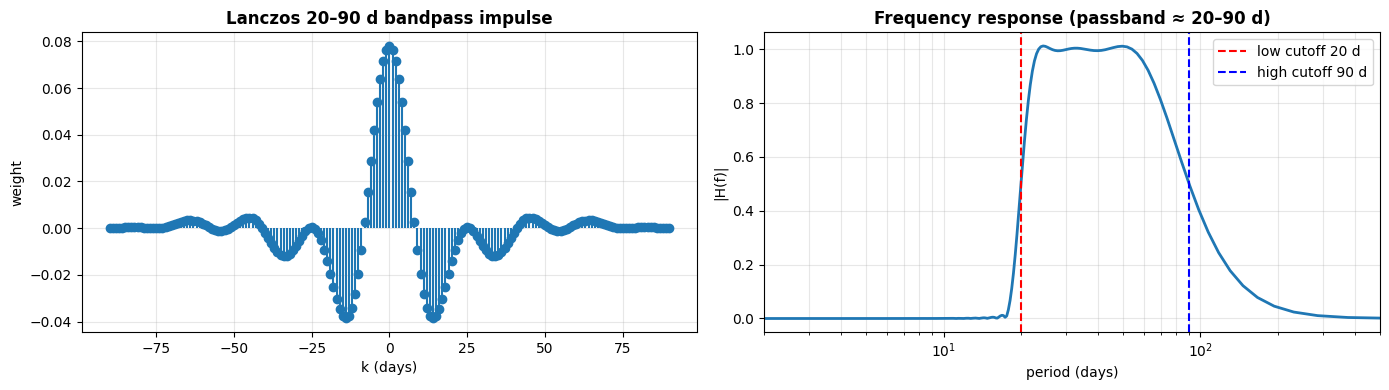


Applying bandpass to full continuous time series ...

Before drop: 16436 samples
After drop:  16256 samples  (98.9%)
Date range:  1979-04-01 to 2023-10-02

Saved: X_MJO_bp20_90.npy shape (16256, 3, 1, 180)
Saved: labels_aligned_mjo_bp20_90.csv  rows 16256

Variance (channel-mean over space) — raw vs bandpassed:
  u850: raw var=0.9918, bp var=0.3763  (ratio=37.94%)
  OLR: raw var=1.0023, bp var=0.2684  (ratio=26.78%)
  u200: raw var=1.0179, bp var=0.4264  (ratio=41.89%)


In [3]:
def lanczos_lowpass_weights(cutoff_days, half_window):
    """Lanczos-windowed sinc lowpass. Passes periods > cutoff_days."""
    k = np.arange(-half_window, half_window + 1)
    fc = 1.0 / cutoff_days
    h = np.where(k == 0, 2*fc, np.sin(2*np.pi*fc*k) / (np.pi*k))
    sigma = np.where(k == 0, 1.0, np.sin(np.pi*k/half_window) / (np.pi*k/half_window))
    w = h * sigma
    w /= w.sum()
    return w

def lanczos_bandpass_weights(low_period, high_period, half_window):
    """Bandpass passing periods in (low_period, high_period). low < high in days."""
    w_low  = lanczos_lowpass_weights(low_period,  half_window)
    w_high = lanczos_lowpass_weights(high_period, half_window)
    return w_low - w_high

weights = lanczos_bandpass_weights(BP_LOW_DAYS, BP_HIGH_DAYS, BP_HALF_W)
print(f'Filter length:    {len(weights)} taps (half_w={BP_HALF_W})')
print(f'Sum of weights:   {weights.sum():.6f}  (should be ≈ 0 — bandpass has zero DC gain)')
print(f'Peak |weight|:    {np.abs(weights).max():.4f}')

# Frequency response (sanity)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].stem(np.arange(-BP_HALF_W, BP_HALF_W+1), weights, basefmt=' ')
axes[0].set_xlabel('k (days)'); axes[0].set_ylabel('weight')
axes[0].set_title(f'Lanczos {BP_LOW_DAYS}–{BP_HIGH_DAYS} d bandpass impulse', fontweight='bold')
axes[0].grid(alpha=0.3)

freqs = np.linspace(0.001, 0.5, 600)
k_arr = np.arange(-BP_HALF_W, BP_HALF_W+1)
response = np.abs(np.array([np.sum(weights * np.exp(-2j*np.pi*f*k_arr)) for f in freqs]))
periods = 1.0 / freqs
axes[1].plot(periods, response, linewidth=2)
axes[1].axvline(BP_LOW_DAYS,  color='red',  linestyle='--', label=f'low cutoff {BP_LOW_DAYS} d')
axes[1].axvline(BP_HIGH_DAYS, color='blue', linestyle='--', label=f'high cutoff {BP_HIGH_DAYS} d')
axes[1].set_xscale('log'); axes[1].set_xlabel('period (days)'); axes[1].set_ylabel('|H(f)|')
axes[1].set_title('Frequency response (passband ≈ 20–90 d)', fontweight='bold')
axes[1].set_xlim(2, 500); axes[1].legend(); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/bandpass_filter_response.png', dpi=130, bbox_inches='tight')
plt.show()

# Apply filter to full continuous record
print('\nApplying bandpass to full continuous time series ...')
X_filt = convolve1d(X.astype(np.float64), weights, axis=0, mode='reflect').astype(np.float32)

# Drop edges
T = len(X)
mask_keep = np.zeros(T, dtype=bool)
mask_keep[EDGE_DROP_DAYS : T - EDGE_DROP_DAYS] = True

X_bp = X_filt[mask_keep]
labels_bp = labels.loc[mask_keep].reset_index(drop=True)

print(f'\nBefore drop: {T} samples')
print(f'After drop:  {len(X_bp)} samples  ({100*len(X_bp)/T:.1f}%)')
print(f'Date range:  {labels_bp["date"].min().date()} to {labels_bp["date"].max().date()}')

np.save(f'{PROCESSED_DIR}/{X_BP_FILE}', X_bp)
labels_bp.to_csv(f'{PROCESSED_DIR}/{LABELS_BP_FILE}', index=False)
print(f'\nSaved: {X_BP_FILE} shape {X_bp.shape}')
print(f'Saved: {LABELS_BP_FILE}  rows {len(labels_bp)}')

# Variance comparison
print('\nVariance (channel-mean over space) — raw vs bandpassed:')
for ch, name in enumerate(['u850', 'OLR', 'u200']):
    v_raw = X[mask_keep, ch].var()
    v_bp  = X_bp[:, ch].var()
    print(f'  {name}: raw var={v_raw:.4f}, bp var={v_bp:.4f}  (ratio={v_bp/v_raw:.2%})')

## Cell 4 — Year-Based Train/Val Split (on Bandpassed Data)

In [4]:
all_years = sorted(labels_bp['date'].dt.year.unique())
val_years = all_years[::5]
train_years = [y for y in all_years if y not in val_years]

year_col = labels_bp['date'].dt.year
train_idx = labels_bp.index[year_col.isin(train_years)].values
val_idx   = labels_bp.index[year_col.isin(val_years)].values

print(f'Val years ({len(val_years)}): {val_years}')
print(f'Train: {len(train_idx)} samples ({100*len(train_idx)/len(labels_bp):.1f}%)')
print(f'Val:   {len(val_idx)} samples ({100*len(val_idx)/len(labels_bp):.1f}%)')
print(f'\nENSO distribution (val):')
print(labels_bp.loc[val_idx, 'enso_category'].value_counts())

Val years (9): [np.int32(1979), np.int32(1984), np.int32(1989), np.int32(1994), np.int32(1999), np.int32(2004), np.int32(2009), np.int32(2014), np.int32(2019)]
Train: 13059 samples (80.3%)
Val:   3197 samples (19.7%)

ENSO distribution (val):
enso_category
Neutral    1462
La Nina    1002
El Nino     733
Name: count, dtype: int64


## Cell 5 — SSL Temporal Pair Sampler + Dataset

Same logic as nb08. Pairs defined by temporal proximity only — model never sees RMM phase or ENSO during training.

In [5]:
class TemporalPairSampler:
    def __init__(self, labels_df, allowed_indices, max_delta=3):
        self.labels = labels_df
        self.allowed_set = set(int(i) for i in allowed_indices)
        self.max_delta = max_delta
        sub = labels_df.loc[list(self.allowed_set)]
        self.date_to_idx = {pd.Timestamp(d): int(i)
                            for d, i in zip(sub['date'].values, sub.index.values)}

    def sample_positive_pair(self, anchor_idx):
        anchor_date = self.labels.loc[anchor_idx, 'date']
        anchor_year = anchor_date.year
        candidates = []
        for delta in range(-self.max_delta, self.max_delta + 1):
            if delta == 0: continue
            target = anchor_date + pd.Timedelta(days=delta)
            if target.year != anchor_year: continue
            key = pd.Timestamp(target)
            if key in self.date_to_idx:
                candidates.append(self.date_to_idx[key])
        if not candidates:
            return anchor_idx, anchor_idx
        return anchor_idx, int(np.random.choice(candidates))


class SSLTemporalDataset(Dataset):
    def __init__(self, X_data, labels_df, train_indices, max_delta=3, mode='train', n_val_pairs=1000):
        self.X = X_data
        self.labels = labels_df
        self.train_indices = np.asarray(train_indices)
        self.sampler = TemporalPairSampler(labels_df, train_indices, max_delta)
        self.mode = mode
        if mode == 'val':
            rng = np.random.default_rng(42)
            self.val_pairs = []
            for idx in rng.choice(self.train_indices,
                                  size=min(n_val_pairs * 2, len(self.train_indices)), replace=False):
                a, b = self.sampler.sample_positive_pair(int(idx))
                if a != b: self.val_pairs.append((a, b))
                if len(self.val_pairs) >= n_val_pairs: break

    def __len__(self):
        return len(self.train_indices) if self.mode == 'train' else len(self.val_pairs)

    def __getitem__(self, idx):
        if self.mode == 'train':
            anchor = int(self.train_indices[idx])
            a, b = self.sampler.sample_positive_pair(anchor)
        else:
            a, b = self.val_pairs[idx]
        return torch.from_numpy(self.X[a]).float(), torch.from_numpy(self.X[b]).float()


train_dataset = SSLTemporalDataset(X_bp, labels_bp, train_idx, max_delta=MAX_DELTA, mode='train')
val_dataset   = SSLTemporalDataset(X_bp, labels_bp, val_idx,   max_delta=MAX_DELTA, mode='val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} items → {len(train_loader)} batches/epoch')
print(f'Val:   {len(val_dataset)} pairs  → {len(val_loader)} batches')

# Sampler sanity
n_zero = 0
print('\nSample positive pairs (anchor → positive):')
for i in range(10):
    a, b = train_dataset.sampler.sample_positive_pair(int(train_idx[i]))
    da = labels_bp.loc[a, 'date']; db = labels_bp.loc[b, 'date']
    delta_d = (db - da).days
    if delta_d == 0: n_zero += 1
    print(f'  {da.date()} (P{labels_bp.loc[a, "phase"]}) → {db.date()} (P{labels_bp.loc[b, "phase"]})  Δ={delta_d}d')
assert n_zero == 0, f'{n_zero}/10 pairs are (anchor, anchor) — sampler broken.'
assert len(val_dataset) > 0, 'val_dataset is empty.'
print('\n✓ Sampler healthy.')

Train: 13059 items → 205 batches/epoch
Val:   1000 pairs  → 16 batches

Sample positive pairs (anchor → positive):
  1980-01-01 (P4) → 1980-01-02 (P4)  Δ=1d
  1980-01-02 (P4) → 1980-01-01 (P4)  Δ=-1d
  1980-01-03 (P5) → 1980-01-05 (P5)  Δ=2d
  1980-01-04 (P5) → 1980-01-05 (P5)  Δ=1d
  1980-01-05 (P5) → 1980-01-07 (P5)  Δ=2d
  1980-01-06 (P5) → 1980-01-05 (P5)  Δ=-1d
  1980-01-07 (P5) → 1980-01-10 (P5)  Δ=3d
  1980-01-08 (P5) → 1980-01-07 (P5)  Δ=-1d
  1980-01-09 (P5) → 1980-01-08 (P5)  Δ=-1d
  1980-01-10 (P5) → 1980-01-09 (P5)  Δ=-1d

✓ Sampler healthy.


## Cell 6 — Encoder + Loss (same as nb14)

In [6]:
class MJOEncoderNoL2(nn.Module):
    def __init__(self, embedding_dim=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  16, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn1   = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d((1, 2))
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d((1, 2))
        self.conv3 = nn.Conv2d(32, 32, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn3   = nn.BatchNorm2d(32)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc          = nn.Linear(32, embedding_dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).view(x.size(0), -1)
        return self.fc(x)


def InfoNCE_loss_raw(z_A, z_B, temperature):
    sim_matrix = torch.matmul(z_A, z_B.T) / temperature
    labels_ = torch.arange(z_A.size(0), device=z_A.device)
    return F.cross_entropy(sim_matrix, labels_)


def vicreg_terms(z, gamma=1.0, eps=1e-4):
    # VICReg variance+covariance (nb07d collapse fix): variance hinge + decorrelation
    z = z - z.mean(0, keepdim=True)
    std = torch.sqrt(z.var(0) + eps)
    var_loss = torch.mean(F.relu(gamma - std))
    B, D = z.shape
    cov = (z.T @ z) / (B - 1)
    off = cov - torch.diag(torch.diag(cov))
    cov_loss = off.pow(2).sum() / D
    return var_loss, cov_loss

encoder = MJOEncoderNoL2(embedding_dim=EMBEDDING_DIM).to(device)
optimizer = optim.Adam(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f'Parameters: {sum(p.numel() for p in encoder.parameters()):,}')
print(f'Training:   {EPOCHS} epochs, batch {BATCH_SIZE}, τ={TEMPERATURE}, weight_decay={WEIGHT_DECAY}')

Parameters: 4,978
Training:   50 epochs, batch 64, τ=0.5, weight_decay=0.0001


## Cell 7 — Training Loop

In [7]:
from tqdm.notebook import tqdm
assert len(train_loader) > 0 and len(val_loader) > 0

history = {'train_loss': [], 'val_loss': [], 'epoch_time': [],
           'mean_norm': [], 'std_norm': [], 'max_norm': []}

for epoch in range(EPOCHS):
    t0 = time.time()
    encoder.train()
    train_loss = 0.0
    epoch_norms = []
    pbar = tqdm(train_loader, desc=f'ep {epoch+1}/{EPOCHS}', leave=False)
    for fA, fB in pbar:
        fA = fA.to(device, non_blocking=True); fB = fB.to(device, non_blocking=True)
        zA = encoder(fA); zB = encoder(fB)
        with torch.no_grad():
            epoch_norms.extend(zA.norm(dim=1).cpu().numpy().tolist())
            epoch_norms.extend(zB.norm(dim=1).cpu().numpy().tolist())
        loss = InfoNCE_loss_raw(zA, zB, temperature=TEMPERATURE)
        if USE_VICREG:
            vA, cA = vicreg_terms(zA); vB, cB = vicreg_terms(zB)
            loss = loss + VICREG_VAR * (vA + vB) / 2 + VICREG_COV * (cA + cB) / 2
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    train_loss /= len(train_loader)

    encoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for fA, fB in val_loader:
            fA = fA.to(device, non_blocking=True); fB = fB.to(device, non_blocking=True)
            zA = encoder(fA); zB = encoder(fB)
            val_loss += InfoNCE_loss_raw(zA, zB, temperature=TEMPERATURE).item()
    val_loss = val_loss / len(val_loader)
    scheduler.step()

    en = np.array(epoch_norms); et = time.time() - t0
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['epoch_time'].append(et)
    history['mean_norm'].append(float(en.mean())); history['std_norm'].append(float(en.std()))
    history['max_norm'].append(float(en.max()))
    print(f'ep {epoch+1:2d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  '
          f'norm μ={en.mean():.3f} σ={en.std():.3f} max={en.max():.2f}  '
          f'lr={scheduler.get_last_lr()[0]:.2e}  time={et:.1f}s')

    if (epoch + 1) % 10 == 0:
        torch.save({'epoch': epoch+1, 'model_state_dict': encoder.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_loss': train_loss, 'val_loss': val_loss},
                   f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_epoch_{epoch+1}.pth')

torch.save(encoder.state_dict(), f'{CHECKPOINT_DIR}/encoder_{RUN_TAG}_final.pth')
with open(f'{CHECKPOINT_DIR}/training_history_{RUN_TAG}.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\nTraining complete. Total time: {sum(history["epoch_time"])/60:.1f} min')
print(f'Final mean norm: {history["mean_norm"][-1]:.3f}  max norm: {history["max_norm"][-1]:.2f}')

ep 1/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep  1/50  train=3.6588  val=3.2856  norm μ=0.609 σ=0.445 max=2.96  lr=9.99e-04  time=6.5s


ep 2/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep  2/50  train=3.1443  val=3.1644  norm μ=1.050 σ=0.462 max=3.28  lr=9.96e-04  time=4.0s


ep 3/50:   0%|          | 0/205 [00:00<?, ?it/s]

...

ep 48/50  train=3.0222  val=3.1231  norm μ=1.196 σ=0.447 max=2.55  lr=1.39e-05  time=3.8s


ep 49/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep 49/50  train=3.0203  val=3.1424  norm μ=1.194 σ=0.447 max=2.40  lr=1.10e-05  time=4.4s


ep 50/50:   0%|          | 0/205 [00:00<?, ?it/s]

ep 50/50  train=3.0205  val=3.1778  norm μ=1.192 σ=0.447 max=2.33  lr=1.00e-05  time=3.3s

Training complete. Total time: 3.1 min
Final mean norm: 1.192  max norm: 2.33


## Cell 8 — Training Curves

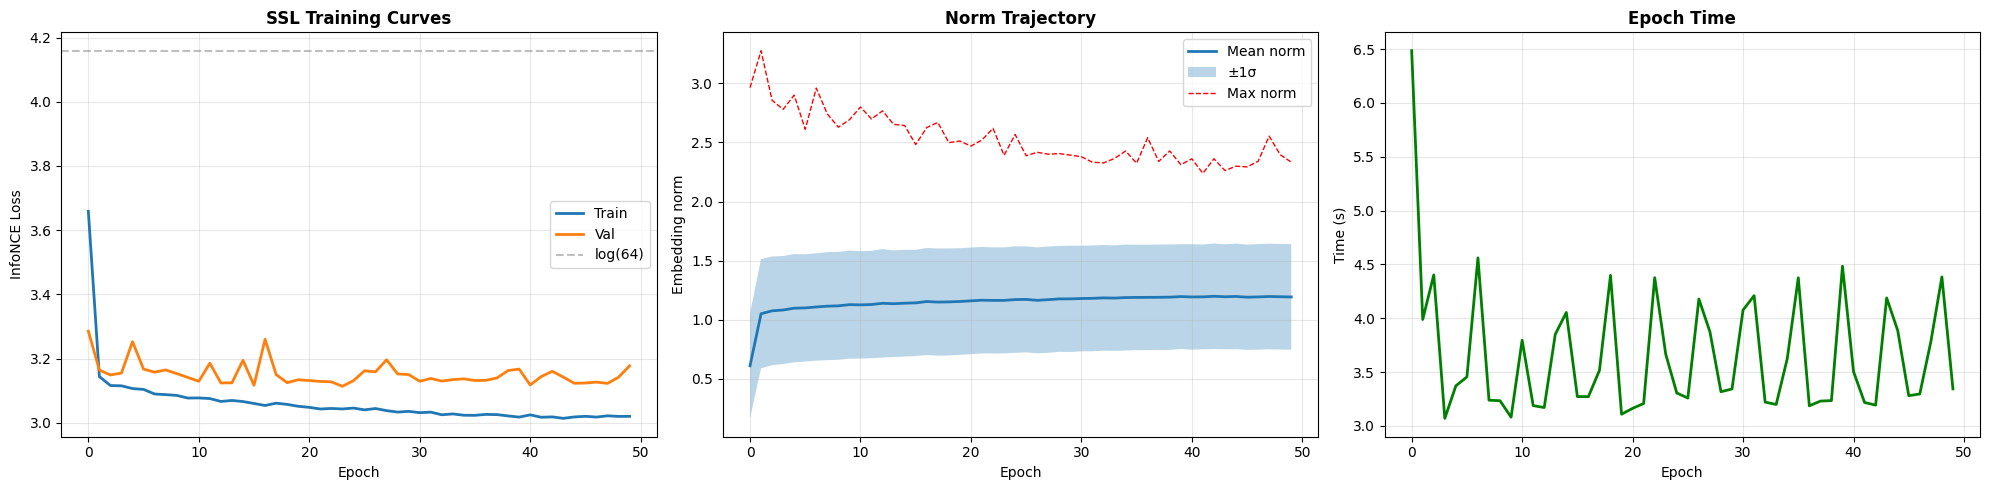


✓ Norms stable (max ever = 3.28)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0].axhline(np.log(64), color='gray', linestyle='--', alpha=0.5, label='log(64)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('InfoNCE Loss')
axes[0].set_title('SSL Training Curves', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['mean_norm'], label='Mean norm', linewidth=2)
axes[1].fill_between(range(len(history['mean_norm'])),
                     np.array(history['mean_norm']) - np.array(history['std_norm']),
                     np.array(history['mean_norm']) + np.array(history['std_norm']),
                     alpha=0.3, label='±1σ')
axes[1].plot(history['max_norm'], label='Max norm', color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Embedding norm')
axes[1].set_title('Norm Trajectory', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch_time'], color='green', linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Time (s)')
axes[2].set_title('Epoch Time', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
if max(history['max_norm']) > 100:
    print('\n⚠️  Norm explosion. Increase WEIGHT_DECAY.')
else:
    print(f'\n✓ Norms stable (max ever = {max(history["max_norm"]):.2f})')

## Cell 9 — Extract Embeddings

In [9]:
encoder.eval()
embeddings_2d = np.zeros((len(X_bp), EMBEDDING_DIM), dtype=np.float32)
with torch.no_grad():
    for start in range(0, len(X_bp), 128):
        end = min(start + 128, len(X_bp))
        batch = torch.from_numpy(X_bp[start:end]).float().to(device)
        embeddings_2d[start:end] = encoder(batch).cpu().numpy()

np.save(f'{RESULTS_DIR}/embeddings.npy', embeddings_2d)
norms = np.linalg.norm(embeddings_2d, axis=1)
angles = np.arctan2(embeddings_2d[:, 1], embeddings_2d[:, 0])
print(f'Embeddings shape: {embeddings_2d.shape}')
print(f'Norm:  min={norms.min():.3f}  max={norms.max():.3f}  mean={norms.mean():.3f}  std={norms.std():.3f}')
print(f'Angle: spread = {angles.max() - angles.min():.3f} rad')

Embeddings shape: (16256, 2)
Norm:  min=0.010  max=2.390  mean=1.196  std=0.453
Angle: spread = 6.282 rad


## Cell 10 — 4-Panel Scatter: by Phase, ENSO, Calendar Month, Amplitude

**Critical confound check (panel 3 — calendar month):** For all-year MJO data, the seasonal cycle is much stronger than for BSISO MJJAS. If embeddings cluster strongly by month, the bandpass wasn't enough — the model is learning "this is winter" rather than "this is MJO phase X".

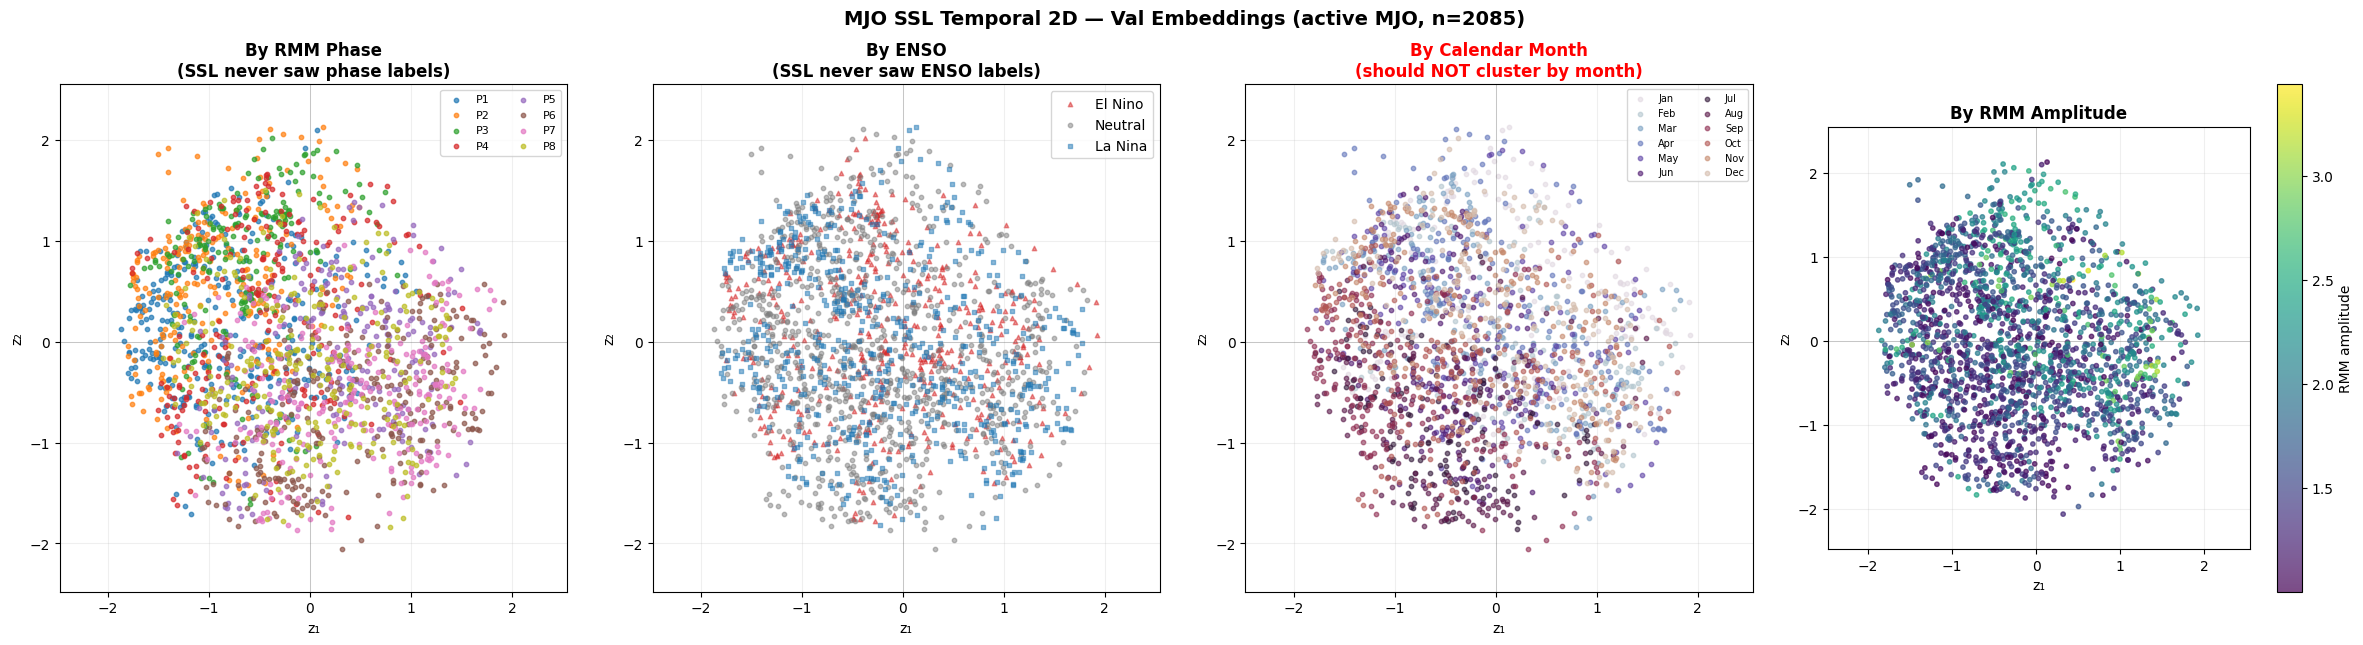

In [10]:
# Show val active MJO days for clarity
lv = labels_bp.loc[val_idx]
act_v = (~lv['weak_mjo'].values) & (lv['phase'].between(1, 8).values)
Z_val = embeddings_2d[val_idx][act_v]
lv_a  = lv[act_v]

phase_colors = plt.cm.tab10(np.linspace(0, 0.8, 8))
enso_palette = {'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}
enso_marker  = {'El Nino': '^',       'Neutral': 'o',        'La Nina': 's'}
month_colors = plt.cm.twilight(np.linspace(0, 1, 13))[:12]   # cyclic colors for 12 months
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

rng_lo = min(Z_val.min(), -1.0); rng_hi = max(Z_val.max(), 1.0)
pad = 0.1 * (rng_hi - rng_lo); rng_lo -= pad; rng_hi += pad

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# (a) by RMM phase
ax = axes[0]
for ph in range(1, 9):
    m = lv_a['phase'] == ph
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=[phase_colors[ph-1]], s=10, alpha=0.7, label=f'P{ph}')
ax.set_title('By RMM Phase\n(SSL never saw phase labels)', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.2)

# (b) by ENSO
ax = axes[1]
for cat in ['El Nino', 'Neutral', 'La Nina']:
    m = lv_a['enso_category'] == cat
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=enso_palette[cat], marker=enso_marker[cat], s=10, alpha=0.5, label=cat)
ax.set_title('By ENSO\n(SSL never saw ENSO labels)', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(); ax.grid(alpha=0.2)

# (c) by CALENDAR MONTH — the critical confound check (12 months for all-year MJO)
ax = axes[2]
months = lv_a['date'].dt.month.values
for mi in range(1, 13):
    m = months == mi
    if m.sum() == 0: continue
    ax.scatter(Z_val[m, 0], Z_val[m, 1], c=[month_colors[mi-1]], s=10, alpha=0.6, label=month_names[mi-1])
ax.set_title('By Calendar Month\n(should NOT cluster by month)', fontweight='bold', color='red')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc='best'); ax.grid(alpha=0.2)

# (d) by amplitude
ax = axes[3]
sc = ax.scatter(Z_val[:, 0], Z_val[:, 1], c=lv_a['amplitude'].values, cmap='viridis', s=10, alpha=0.7)
ax.set_title('By RMM Amplitude', fontweight='bold')
ax.set_xlabel('z₁'); ax.set_ylabel('z₂')
ax.set_aspect('equal'); ax.set_xlim(rng_lo, rng_hi); ax.set_ylim(rng_lo, rng_hi)
ax.axhline(0, color='k', lw=0.4, alpha=0.3); ax.axvline(0, color='k', lw=0.4, alpha=0.3)
plt.colorbar(sc, ax=ax, label='RMM amplitude'); ax.grid(alpha=0.2)

plt.suptitle(f'MJO SSL Temporal 2D — Val Embeddings (active MJO, n={len(Z_val)})',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/embedding_2d_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Month-Clustering Confound Check (formal ANOVA)

For all-year MJO with 12 months, this is more stringent than BSISO's 5-month version. Threshold: angle ANOVA F > 50 → strong seasonal confound.

Angle by month  ANOVA: F = 300.84  p = 0.00e+00
Radius by month ANOVA: F = 214.60  p = 0.00e+00


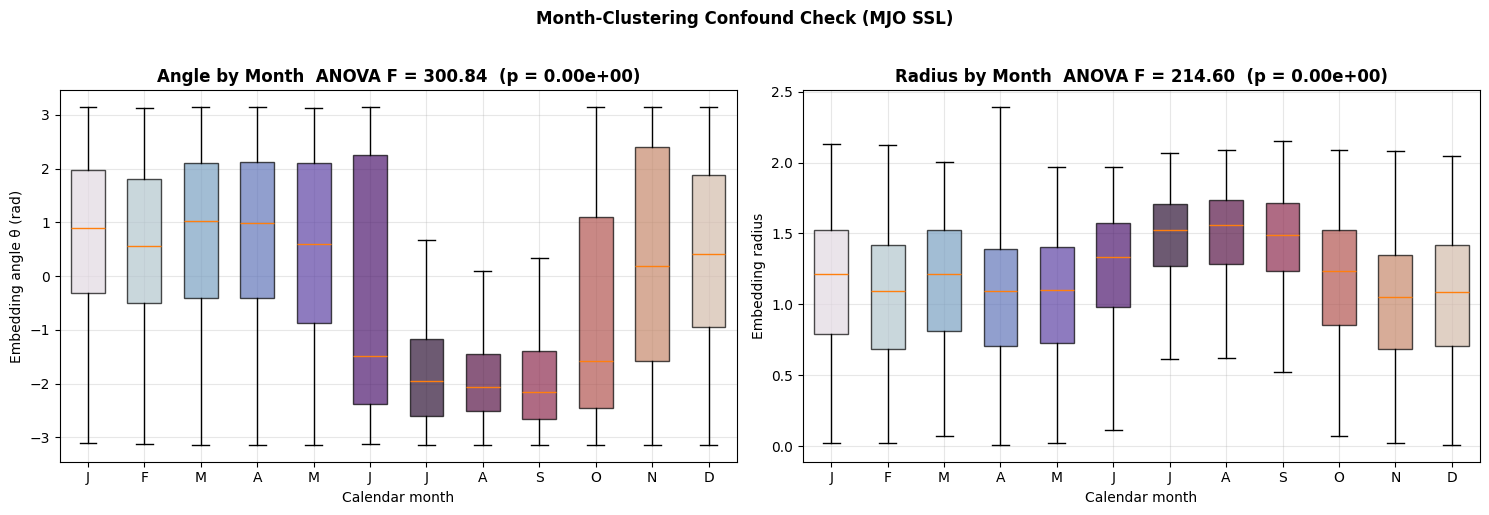


⚠️  Strong month confound on angle (F=301). Bandpass insufficient — consider tightening to (20,60) or restricting negatives to same month.


In [11]:
from scipy.stats import f_oneway

angles_all = np.arctan2(embeddings_2d[:, 1], embeddings_2d[:, 0])
radii_all  = np.linalg.norm(embeddings_2d, axis=1)
months_all = labels_bp['date'].dt.month.values

angles_by_month = [angles_all[months_all == m] for m in range(1, 13)]
radii_by_month  = [radii_all[months_all == m]  for m in range(1, 13)]

f_a, p_a = f_oneway(*angles_by_month)
f_r, p_r = f_oneway(*radii_by_month)
print(f'Angle by month  ANOVA: F = {f_a:.2f}  p = {p_a:.2e}')
print(f'Radius by month ANOVA: F = {f_r:.2f}  p = {p_r:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
bp = ax.boxplot(angles_by_month, positions=range(1, 13), widths=0.6, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], plt.cm.twilight(np.linspace(0, 1, 13))[:12]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_xlabel('Calendar month'); ax.set_ylabel('Embedding angle θ (rad)')
ax.set_title(f'Angle by Month  ANOVA F = {f_a:.2f}  (p = {p_a:.2e})', fontweight='bold')
ax.grid(alpha=0.3)

ax = axes[1]
bp = ax.boxplot(radii_by_month, positions=range(1, 13), widths=0.6, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], plt.cm.twilight(np.linspace(0, 1, 13))[:12]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_xlabel('Calendar month'); ax.set_ylabel('Embedding radius')
ax.set_title(f'Radius by Month  ANOVA F = {f_r:.2f}  (p = {p_r:.2e})', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Month-Clustering Confound Check (MJO SSL)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/month_clustering_check.png', dpi=150, bbox_inches='tight')
plt.show()

if f_a > 50:
    print(f'\n⚠️  Strong month confound on angle (F={f_a:.0f}). Bandpass insufficient — consider tightening to (20,60) or restricting negatives to same month.')
elif f_a > 10:
    print(f'\n△ Moderate month dependence (F={f_a:.1f}). May reflect real intraseasonal amplitude modulation across the annual cycle.')
else:
    print(f'\n✓ Month dependence on angle is weak (F={f_a:.1f}). Confound under control.')

## Cell 12 — Linear Probes (RMM Phase + ENSO Balanced)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, GroupKFold

# Probe over active MJO days only (consistent with how RMM phase is defined)
active_mask = (~labels_bp['weak_mjo'].values) & (labels_bp['phase'].between(1, 8).values)
active_idx = np.where(active_mask)[0]
train_act  = np.intersect1d(train_idx, active_idx)
val_act    = np.intersect1d(val_idx,   active_idx)

Z_train = embeddings_2d[train_act]
Z_val_  = embeddings_2d[val_act]
year_groups_act = labels_bp.loc[active_idx, 'date'].dt.year.values
gkf = GroupKFold(n_splits=5)

# RMM phase
y_tr = labels_bp.loc[train_act, 'phase'].values
y_va = labels_bp.loc[val_act,   'phase'].values
clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(Z_train, y_tr)
phase_val = float(accuracy_score(y_va, clf.predict(Z_val_)))
cv_phase = cross_val_score(clf, embeddings_2d[active_idx], labels_bp.loc[active_idx, 'phase'].values,
                            cv=gkf, groups=year_groups_act, scoring='accuracy', n_jobs=-1)

# ENSO balanced
y_tr_e = labels_bp.loc[train_act, 'enso_category'].values
y_va_e = labels_bp.loc[val_act,   'enso_category'].values
clf_b = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced')
clf_b.fit(Z_train, y_tr_e)
enso_bal = float(balanced_accuracy_score(y_va_e, clf_b.predict(Z_val_)))
cv_enso = cross_val_score(clf_b, embeddings_2d[active_idx], labels_bp.loc[active_idx, 'enso_category'].values,
                           cv=gkf, groups=year_groups_act, scoring='balanced_accuracy', n_jobs=-1)

probe_results = {
    'RMM Phase': {'val_acc': phase_val,  'cv_mean': float(cv_phase.mean()), 'cv_std': float(cv_phase.std())},
    'ENSO bal':  {'val_acc': enso_bal,   'cv_mean': float(cv_enso.mean()),  'cv_std': float(cv_enso.std())},
}

print('=' * 70)
print('MJO SSL — LINEAR PROBE RESULTS (no labels seen during training)')
print('=' * 70)
print(f'RMM phase val acc:    {phase_val*100:.1f}%   (random 12.5%)')
print(f'RMM phase 5-fold CV:  {cv_phase.mean()*100:.1f}% ± {cv_phase.std()*100:.1f}%')
print(f'ENSO  bal-acc val:    {enso_bal*100:.1f}%   (random 33.3%)')
print(f'ENSO  bal-acc 5-fold: {cv_enso.mean()*100:.1f}% ± {cv_enso.std()*100:.1f}%')
print(f'\nReference (BSISO):')
print(f'  64D supervised:   phase 67.7%, z=3.83')
print(f'  2D supervised:    phase 58.3%, z=2.53')
print(f'  2D SSL temporal:  phase ~30-40%, z=14.55 (key result: ENSO emergence without labels)')

with open(f'{RESULTS_DIR}/linear_probe_results.json', 'w') as f:
    json.dump(probe_results, f, indent=2)

MJO SSL — LINEAR PROBE RESULTS (no labels seen during training)
RMM phase val acc:    24.7%   (random 12.5%)
RMM phase 5-fold CV:  27.3% ± 1.6%
ENSO  bal-acc val:    35.7%   (random 33.3%)
ENSO  bal-acc 5-fold: 34.9% ± 4.1%

Reference (BSISO):
  64D supervised:   phase 67.7%, z=3.83
  2D supervised:    phase 58.3%, z=2.53
  2D SSL temporal:  phase ~30-40%, z=14.55 (key result: ENSO emergence without labels)


## Cell 13 — ENSO Displacement Z-Score

**The headline test:** does ENSO modulation emerge in the SSL embedding without the model being told ENSO categories? If z is large (≥ 5), SSL discovered ENSO-modulated MJO structure from temporal continuity alone — directly parallels the BSISO finding (z=14.55).

EN−LN displacement summary (MJO SSL):
  Observed mean: 0.3208
  Null baseline: 0.0736 ± 0.0132
  Z-score:       18.74
  (BSISO SSL: z=14.55; BSISO supervised 2D: z=2.53)


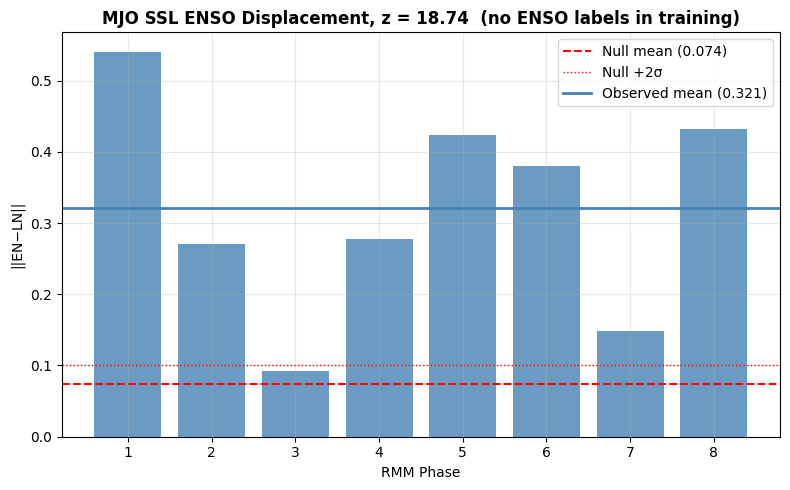

In [13]:
labels_act = labels_bp.loc[active_mask].reset_index(drop=True)
emb_act = embeddings_2d[active_mask]

phases = range(1, 9)
disp_mag = []
for ph in phases:
    mEN = (labels_act['phase'] == ph) & (labels_act['enso_category'] == 'El Nino')
    mLN = (labels_act['phase'] == ph) & (labels_act['enso_category'] == 'La Nina')
    if mEN.sum() < 3 or mLN.sum() < 3:
        disp_mag.append(np.nan); continue
    cEN = emb_act[mEN].mean(axis=0); cLN = emb_act[mLN].mean(axis=0)
    disp_mag.append(np.linalg.norm(cEN - cLN))

rng = np.random.default_rng(42)
baseline_mag = []
for _ in range(100):
    shuf = labels_act['enso_category'].sample(frac=1, random_state=rng.integers(1e6)).values
    mtrl = []
    for ph in phases:
        mph = (labels_act['phase'] == ph).values
        mEN = mph & (shuf == 'El Nino'); mLN = mph & (shuf == 'La Nina')
        if mEN.sum() < 3 or mLN.sum() < 3: continue
        mtrl.append(np.linalg.norm(emb_act[mEN].mean(axis=0) - emb_act[mLN].mean(axis=0)))
    if mtrl: baseline_mag.append(np.mean(mtrl))

bmu = float(np.mean(baseline_mag)); bsd = float(np.std(baseline_mag))
obs_mu = float(np.nanmean(disp_mag))
z_score_ssl = float((obs_mu - bmu) / (bsd + 1e-8))

print(f'EN−LN displacement summary (MJO SSL):')
print(f'  Observed mean: {obs_mu:.4f}')
print(f'  Null baseline: {bmu:.4f} ± {bsd:.4f}')
print(f'  Z-score:       {z_score_ssl:.2f}')
print(f'  (BSISO SSL: z=14.55; BSISO supervised 2D: z=2.53)')

fig, ax = plt.subplots(figsize=(8, 5))
valid_p = [p for p, m in zip(phases, disp_mag) if not np.isnan(m)]
valid_m = [m for m in disp_mag if not np.isnan(m)]
ax.bar(valid_p, valid_m, color='steelblue', alpha=0.8)
ax.axhline(bmu, color='red', linestyle='--', linewidth=1.5, label=f'Null mean ({bmu:.3f})')
ax.axhline(bmu + 2*bsd, color='red', linestyle=':', linewidth=1, label='Null +2σ')
ax.axhline(obs_mu, color='steelblue', linewidth=2, label=f'Observed mean ({obs_mu:.3f})')
ax.set_xticks(range(1, 9))
ax.set_xlabel('RMM Phase'); ax.set_ylabel('||EN−LN||')
ax.set_title(f'MJO SSL ENSO Displacement, z = {z_score_ssl:.2f}  (no ENSO labels in training)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/enso_displacement.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — MJO SSL Summary + Auto-Decision

In [16]:
import time as _t

# References for context
BSISO_REF = {
    '64D supervised (BSISO)':         {'phase_val': 0.677, 'phase_cv': '68.6% ± 1.0%', 'enso_bal': 'n/a',  'z': 3.83,  'labels': 'phase + ENSO'},
    '2D supervised (BSISO, nb07c)':   {'phase_val': 0.583, 'phase_cv': '65.7% ± 4.1%', 'enso_bal': '34.6%','z': 2.53,  'labels': 'phase + ENSO'},
    '2D SSL temporal (BSISO, nb08)':  {'phase_val': 0.30,  'phase_cv': '~30-40%',       'enso_bal': '~33%', 'z': 14.55, 'labels': 'none'},
}

rows = []
for name, b in BSISO_REF.items():
    rows.append([name, f"{b['phase_val']*100:.1f}%" if isinstance(b['phase_val'], float) else str(b['phase_val']),
                 b['phase_cv'], str(b['enso_bal']), f"{b['z']:.2f}", b['labels']])
rows.append(['**MJO 2D SSL temporal (this nb)**', f'{phase_val*100:.1f}%',
             f'{cv_phase.mean()*100:.1f}% ± {cv_phase.std()*100:.1f}%',
             f'{enso_bal*100:.1f}%', f'{z_score_ssl:.2f}', '**none (temporal only)**'])
df_comp = pd.DataFrame(rows, columns=['Configuration', 'Phase val', 'Phase CV', 'ENSO bal', 'z-score', 'Labels in training'])

print('=' * 130)
print('MJO SSL SUMMARY — Compared against BSISO References')
print('=' * 130)
print(df_comp.to_string(index=False))

# Auto-decision
month_confound = f_a > 50
phase_pass     = phase_val >= 0.30      # weaker than supervised but well above 12.5% random
z_pass         = z_score_ssl >= 3.0
ssl_advantage  = z_score_ssl > 2.53     # exceeds BSISO supervised baseline
no_signal      = phase_val < 0.20

if month_confound:
    decision = 'MONTH_CONFOUND'
    decision_text = (f"**Seasonal confound detected** (angle ANOVA F={f_a:.1f} > 50). "
                     f"The {BP_LOW_DAYS}–{BP_HIGH_DAYS} d bandpass was insufficient to remove the annual cycle. "
                     f"Recommend: tighten bandpass to (20, 60) d, or restrict negatives to same calendar month.")
elif phase_pass and ssl_advantage:
    decision = 'GREENLIGHT_NB16_KEY_RESULT'
    decision_text = (f"**Key result: SSL captures ENSO modulation more strongly than supervised** "
                     f"(SSL z={z_score_ssl:.2f} > BSISO sup baseline z=2.53). "
                     f"This parallels the BSISO finding and suggests the SSL advantage is a general property "
                     f"of temporal contrastive learning, not specific to boreal summer monsoon dynamics. "
                     f"→ **Greenlight nb16** (three-way comparison: RMM vs supervised vs SSL).")
elif phase_pass and z_pass:
    decision = 'GREENLIGHT_NB16'
    decision_text = (f"SSL discovered some phase + ENSO structure without labels (phase {phase_val*100:.1f}%, z={z_score_ssl:.2f}). "
                     f"Less pronounced SSL advantage than BSISO but still significant. → Greenlight nb16.")
elif no_signal:
    decision = 'NO_SIGNAL'
    decision_text = (f"Temporal continuity alone insufficient (phase {phase_val*100:.1f}% near random). "
                     f"Revisit bandpass design, pair window, or architecture.")
else:
    decision = 'PARTIAL'
    decision_text = (f"Partial signal (phase {phase_val*100:.1f}%, z={z_score_ssl:.2f}). "
                     f"Document and discuss with advisor before nb16.")

print('\n' + '=' * 70)
print(f'DECISION: {decision}')
print('=' * 70)
print(decision_text)

summary = f"""# MJO SSL Temporal 2D Summary

**Auto-generated by notebook 15.**
**Date:** {_t.strftime('%Y-%m-%d')}
**Model:** `encoder_{RUN_TAG}_final.pth`, no L2 norm, τ={TEMPERATURE}, weight_decay={WEIGHT_DECAY}
**Pairs:** anchor d, positive in [d−{MAX_DELTA}, d+{MAX_DELTA}] \\ {{d}}, same year. **No RMM/ENSO labels.**
**Bandpass:** Lanczos {BP_LOW_DAYS}–{BP_HIGH_DAYS} d, half-window {BP_HALF_W} d, edge drop ±{EDGE_DROP_DAYS} d. Result: {len(X_bp)} samples (from {len(X)}).

## Headline comparison

{df_comp.to_markdown(index=False)}

## Month-clustering confound check

- Angle  ANOVA F = {f_a:.2f}  p = {p_a:.2e}
- Radius ANOVA F = {f_r:.2f}  p = {p_r:.2e}
- Threshold: F > 50 = strong confound. {'⚠️  STRONG CONFOUND DETECTED' if f_a > 50 else '✓ confound under control' if f_a < 10 else '△ moderate'}

## Decision

{decision_text}

## Files produced

```
checkpoints/encoder_{RUN_TAG}_final.pth
checkpoints/training_history_{RUN_TAG}.json
data/processed/X_MJO_bp20_90.npy         ({len(X_bp)} samples, bandpassed)
data/processed/labels_aligned_mjo_bp20_90.csv
results/ssl/embeddings.npy
results/ssl/bandpass_filter_response.png
results/ssl/training_curves.png
results/ssl/embedding_2d_overview.png
results/ssl/month_clustering_check.png
results/ssl/linear_probe_results.json
results/ssl/enso_displacement.png
results/ssl/mjo_ssl_summary.md  (this file)
```

## Next

- `16_mjo_comparison.ipynb` — three-way comparison: RMM (conventional) vs supervised (nb14) vs SSL (this nb)
"""

with open(f'{RESULTS_DIR}/mjo_ssl_summary.md', 'w') as f:
    f.write(summary)
print(f'\nSaved: {RESULTS_DIR}/mjo_ssl_summary.md')

MJO SSL SUMMARY — Compared against BSISO References
                    Configuration Phase val     Phase CV ENSO bal z-score       Labels in training
           64D supervised (BSISO)     67.7% 68.6% ± 1.0%      n/a    3.83             phase + ENSO
     2D supervised (BSISO, nb07c)     58.3% 65.7% ± 4.1%    34.6%    2.53             phase + ENSO
    2D SSL temporal (BSISO, nb08)     30.0%      ~30-40%     ~33%   14.55                     none
**MJO 2D SSL temporal (this nb)**     24.7% 27.3% ± 1.6%    35.7%   18.74 **none (temporal only)**

DECISION: MONTH_CONFOUND
**Seasonal confound detected** (angle ANOVA F=300.8 > 50). The 20–90 d bandpass was insufficient to remove the annual cycle. Recommend: tighten bandpass to (20, 60) d, or restrict negatives to same calendar month.

Saved: /content/drive/MyDrive/BSISO_SSL_Project/MJO/results/ssl/mjo_ssl_summary.md


## Cell 15 — (Optional) Download Outputs

In [15]:
from google.colab import files
for fname in sorted(os.listdir(RESULTS_DIR)):
    files.download(f'{RESULTS_DIR}/{fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Done!

**Send back:**
1. `mjo_ssl_summary.md` — the auto-decision + comparison table
2. `embedding_2d_overview.png` — 4-panel scatter (the by-phase and by-month panels are the key reads)
3. `month_clustering_check.png` — formal confound check
4. `bandpass_filter_response.png` — sanity that the 20–90 d band is what we wanted
5. `training_curves.png` — norms stable, loss converged
6. `enso_displacement.png` — **the key result** (does ENSO modulation emerge without labels?)

Then we proceed to nb16 (three-way comparison).

---
*DDCS Project | jh9141@nyu.edu*